# 02 - Logistic Regression Baseline
**Project:** Credit Card Default Prediction  
**Model:** Logistic Regression (interpretable baseline)


[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/YinzhiZZZ/MLBA_credit-default-prediction/blob/main/notebooks/02_logistic.ipynb)

In [1]:
# ── Imports ───────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay
)
import joblib

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

In [3]:
# ── Load Data ─────────────────────────────────────────────────────────────────
# Change to 'UCI_Credit_Card.csv' if using Google Colab
DATA_PATH = '../data/UCI_Credit_Card.csv'

df = pd.read_csv(DATA_PATH)
df.columns = list(df.columns[:-1]) + ['default']

print(f'Dataset shape: {df.shape}')
print(f'Default rate: {df["default"].mean():.2%}')

Dataset shape: (30000, 25)
Default rate: 22.12%


In [4]:
# ── Feature / Target Split ────────────────────────────────────────────────────
# Drop ID column (not a predictive feature) and separate target
X = df.drop(columns=['ID', 'default'])
y = df['default']

print(f'Features: {X.shape[1]}')
print(f'Samples:  {X.shape[0]}')

Features: 23
Samples:  30000


In [5]:
# ── Train / Test Split ────────────────────────────────────────────────────────
# Use stratified split to preserve class ratio in both sets
# 80% train, 20% test — fixed random_state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Train set: {X_train.shape[0]} samples | Default rate: {y_train.mean():.2%}')
print(f'Test set:  {X_test.shape[0]} samples  | Default rate: {y_test.mean():.2%}')

Train set: 24000 samples | Default rate: 22.12%
Test set:  6000 samples  | Default rate: 22.12%


In [6]:
# ── Feature Scaling ───────────────────────────────────────────────────────────
# Logistic Regression is sensitive to feature scale — StandardScaler normalizes
# each feature to mean=0, std=1
# IMPORTANT: fit only on training data, then apply to test data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('Scaling applied: mean=0, std=1 for all features')

Scaling applied: mean=0, std=1 for all features


In [7]:
# ── Train Logistic Regression ─────────────────────────────────────────────────
# class_weight='balanced' adjusts for class imbalance (~22% default)
# max_iter=1000 ensures convergence
lr_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)
lr_model.fit(X_train_scaled, y_train)

print('Model training complete.')

Model training complete.


In [8]:
# ── Cross-Validation (Best Practice) ─────────────────────────────────────────
# 5-fold stratified CV on training data to check model stability
# This guards against overfitting to a single train/test split
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_auc = cross_val_score(lr_model, X_train_scaled, y_train, cv=cv, scoring='roc_auc')
cv_recall = cross_val_score(lr_model, X_train_scaled, y_train, cv=cv, scoring='recall')

print('=== 5-Fold Cross-Validation Results (Train Set) ===')
print(f'AUC-ROC : {cv_auc.mean():.4f} (+/- {cv_auc.std():.4f})')
print(f'Recall  : {cv_recall.mean():.4f} (+/- {cv_recall.std():.4f})')

=== 5-Fold Cross-Validation Results (Train Set) ===
AUC-ROC : 0.7265 (+/- 0.0108)
Recall  : 0.6459 (+/- 0.0159)


In [9]:
# ── Evaluate on Test Set ──────────────────────────────────────────────────────
y_pred      = lr_model.predict(X_test_scaled)
y_pred_prob = lr_model.predict_proba(X_test_scaled)[:, 1]

print('=== Test Set Performance ===')
print(f'Accuracy  : {accuracy_score(y_test, y_pred):.4f}')
print(f'Precision : {precision_score(y_test, y_pred):.4f}')
print(f'Recall    : {recall_score(y_test, y_pred):.4f}')
print(f'F1 Score  : {f1_score(y_test, y_pred):.4f}')
print(f'AUC-ROC   : {roc_auc_score(y_test, y_pred_prob):.4f}')
print('\n=== Classification Report ===')
print(classification_report(y_test, y_pred, target_names=['No Default', 'Default']))

=== Test Set Performance ===
Accuracy  : 0.6797
Precision : 0.3672
Recall    : 0.6202
F1 Score  : 0.4613
AUC-ROC   : 0.7081

=== Classification Report ===
              precision    recall  f1-score   support

  No Default       0.87      0.70      0.77      4673
     Default       0.37      0.62      0.46      1327

    accuracy                           0.68      6000
   macro avg       0.62      0.66      0.62      6000
weighted avg       0.76      0.68      0.70      6000



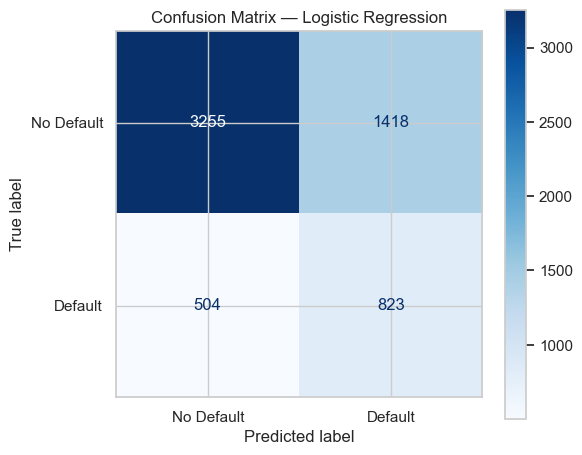

In [10]:
# ── Confusion Matrix ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['No Default', 'Default'],
    cmap='Blues',
    ax=ax
)
ax.set_title('Confusion Matrix — Logistic Regression')
plt.tight_layout()
plt.show()

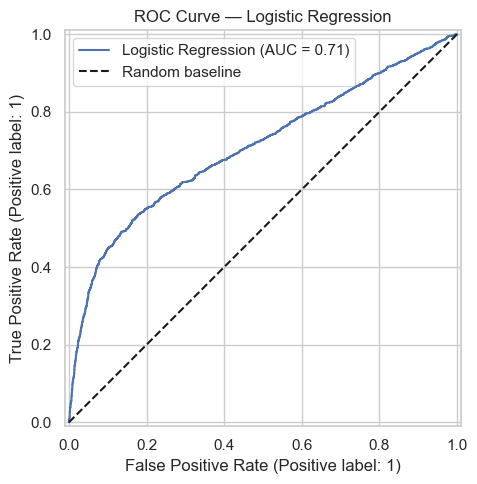

In [11]:
# ── ROC Curve ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_test, y_pred_prob, ax=ax, name='Logistic Regression')
ax.plot([0, 1], [0, 1], 'k--', label='Random baseline')
ax.set_title('ROC Curve — Logistic Regression')
ax.legend()
plt.tight_layout()
plt.show()

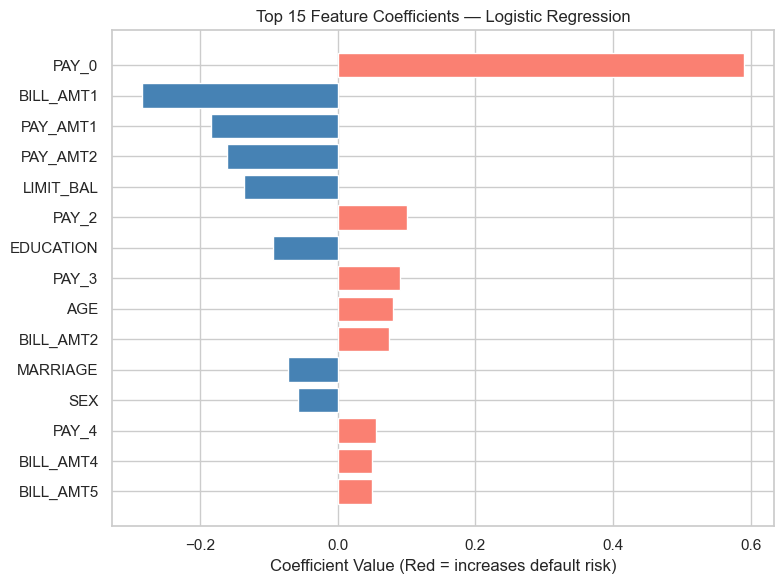

In [12]:
# ── Feature Importance (Coefficients) ────────────────────────────────────────
# In logistic regression, the magnitude of coefficients indicates feature importance
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['salmon' if c > 0 else 'steelblue' for c in coef_df['Coefficient']]
ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
ax.set_title('Top 15 Feature Coefficients — Logistic Regression')
ax.set_xlabel('Coefficient Value (Red = increases default risk)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [13]:
# ── Save Model ────────────────────────────────────────────────────────────────
# Save trained model and scaler for reuse in later notebooks
joblib.dump(lr_model, '../models/logistic_regression.pkl')
joblib.dump(scaler,   '../models/scaler.pkl')

print('Model saved to: models/logistic_regression.pkl')
print('Scaler saved to: models/scaler.pkl')

Model saved to: models/logistic_regression.pkl
Scaler saved to: models/scaler.pkl


In [14]:
# ── Summary ───────────────────────────────────────────────────────────────────
print('=== Logistic Regression Baseline Summary ===')
print(f'AUC-ROC  : {roc_auc_score(y_test, y_pred_prob):.4f}')
print(f'Recall   : {recall_score(y_test, y_pred):.4f}')
print(f'F1 Score : {f1_score(y_test, y_pred):.4f}')
print('\nThis baseline will be compared against Random Forest and XGBoost in notebook 03.')

=== Logistic Regression Baseline Summary ===
AUC-ROC  : 0.7081
Recall   : 0.6202
F1 Score : 0.4613

This baseline will be compared against Random Forest and XGBoost in notebook 03.
